In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import importlib
import datetime as dt
import numpy as np
import random

from trainer import complete_training_loop
from environment import RealGoGame
from nn_numpy import run_neural_net

def set_seed(seed: int = 48):
    """
    Sets the random seed for reproducibility across Python and NumPy.
    """
    random.seed(seed)
    np.random.seed(seed)
    # If you ever add PyTorch later, you would add torch.manual_seed(seed) here too.
    print(f"Random seed set to {seed}")

# --- DIAGNOSTIC: The Empty Board Test ---
def inspect_empty_board(params):
	game = RealGoGame(board_size=3)
	
	# Get raw network prediction (No MCTS)
	policy, value = run_neural_net(game, params)
	
	# 1. Check Value (Who does it think is winning?)
	# Range: -1 (White wins) to +1 (Black wins)
	print(f"Network Evaluation of Empty Board: {value:.4f}")
	if value > 0.5:
		print(">> VERDICT: It correctly knows Black has the advantage.")
	else:
		print(">> VERDICT: It is still unsure (or thinks White is winning).")

	# 2. Check Policy (Where does it want to play?)
	# Reshape the first 9 elements to 3x3 (ignoring the 'pass' move at index 9)
	policy_grid = policy[:9].reshape(3, 3)
	
	print("\nPolicy Probability Map:")
	print(np.round(policy_grid, 3))
	
	# Visual Heatmap
	plt.figure(figsize=(4, 3))
	sns.heatmap(policy_grid, annot=True, cmap="Blues", fmt=".2f")
	plt.title("Where does the AI want to play?")
	plt.show()
	
	# Check if Center is the max
	flat_idx = np.argmax(policy[:9])
	if flat_idx == 4: # Center is index 4 (1,1)
		print(">> SUCCESS: The AI prefers the Center (1,1)!")
	else:
		print(f">> FAIL: The AI prefers index {flat_idx} (Row {flat_idx//3}, Col {flat_idx%3})")

def play_vs_random(params, ai_plays_black=True):
	game = RealGoGame(board_size=3)
	print("--- New Game: AI (Black) vs Random (White) ---" if ai_plays_black else "--- New Game: Random (Black) vs AI (White) ---")
	
	moves = 0
	while not game.is_game_over() and moves < 20:
		# Determine who is playing
		is_ai_turn = (game.current_player == 1 and ai_plays_black) or \
					 (game.current_player == -1 and not ai_plays_black)
		
		if is_ai_turn:
			# AI Move (Using pure Network, no MCTS for speed)
			policy, _ = run_neural_net(game, params)
			# Greedily pick the best move (masking invalid ones logic is simplified here)
			valid_moves = game.get_valid_moves()
			best_score = -1
			best_move = None
			
			for move in valid_moves:
				if move == "PASS": idx = 9
				else: idx = move[0]*3 + move[1]
				
				if policy[idx] > best_score:
					best_score = policy[idx]
					best_move = move
			
			action = best_move
			p_type = "AI Black"
		else:
			# Random Move
			valid_moves = game.get_valid_moves()
			action = valid_moves[np.random.randint(len(valid_moves))]
			p_type = "RND White"
			
		print(f"Move {moves+1} ({p_type}): {action}")
		game.step(action)
		print(game.board)
		moves += 1
		
	winner = game.get_reward()
	if winner == 1: print("Result: Black Wins")
	elif winner == -1: print("Result: White Wins")
	else: print("Result: Draw")

In [2]:
# This takes some time, about 1 game per second, so almost 10 minutes here
tic = dt.datetime.today()
print('Cell Start', tic)

set_seed(48)
params = complete_training_loop(500)
# np.save('my_alphazero_weights.npy', params)
# params = np.load('my_alphazero_weights_16k.npy',allow_pickle=True).item()

Cell Start 2026-03-11 11:37:05.453861
Random seed set to 48
Global Parameters Initialized.
Starting Training Loop for 500 Training Games...
Burn-in phase: waiting for 1000 states before training.

Burn-in progress: 600/1000 states collected...
=== Completed 250 iterations, Time elapsed = 0:03:53.029066, s/game = 0.93 ===
  Buffer Size: 10000
  Avg Loss Value (MSE): 0.1305
  Avg Loss Policy (CE): 1.2454
  Avg Loss L2 Penalty: 0.0084
  Total Loss: 1.3843
------------------------------
=== Completed 500 iterations, Time elapsed = 0:07:36.698962, s/game = 0.91 ===
  Buffer Size: 10000
  Avg Loss Value (MSE): 0.0140
  Avg Loss Policy (CE): 1.1659
  Avg Loss L2 Penalty: 0.0088
  Total Loss: 1.1887
------------------------------

Training Complete


Network Evaluation of Empty Board: 0.9543
>> VERDICT: It correctly knows Black has the advantage.

Policy Probability Map:
[[0.    0.004 0.001]
 [0.004 0.984 0.003]
 [0.    0.003 0.001]]


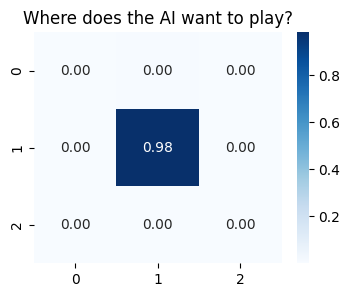

>> SUCCESS: The AI prefers the Center (1,1)!


In [3]:
inspect_empty_board(params)

In [4]:
# play_vs_random(params, ai_plays_black=True)